##### This notebook 

##### ../scripts/1_Fit_GP_model.py
##### ../scripts/2_yeast_marginals_cli.py
##### ../scripts/3_yeast_get_pos_marginals_batched-cli.py

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import sys
import importlib

import os
os.environ['CUDA_PATH'] = '/apps/compilers/cuda/13.2.1' 

import torch
print(f"number of available GPUs = {torch.cuda.device_count()}")
output_device = 'cuda:0'

import vcme
from vcme.functions import prepare_proteingym_data
from vcme.utils import yeast_data, clear_gpu_mem, reload_obj, get_pathway_info
from vcme.utils import tensor_scatter, read_marginal_results, get_gene_interval

from epik.utils import encode_seqs, split_training_test

import epikVC
from epikVC.models import GPModel, make_GP_model, load_GP_model

number of available GPUs = 1


In [2]:
fig_path = '../figures/yeast/'
result_path = '../results/yeast_analysis/5_19/'
# load model fitted using "scripts/get_GP_37C_pruned_snps.py"

# checkpoint_path = '../model_checkpoints/37C_r2_threshold=0.995_MAF_threshold=0/'
checkpoint_path = '../model_checkpoints/37C_r2_threshold=None_MAF_threshold=0/'

geno_path = "/orange/juannanzhou/MarginalEpistasis/data/"
pheno_path = "/orange/juannanzhou/dryad_data/"
out_path = '../results/yeast_analysis/' 
pheno_name = '37C'
model_name = 'GP_model_k=8.model'

In [3]:
# data = yeast_data(geno_path, pheno_path, pheno_name, output_device, prune_snps=True, r2_threshold=0.995, maf_threshold=0)
data = yeast_data(geno_path, pheno_path, pheno_name, output_device, prune_snps=False, r2_threshold=None, maf_threshold=0)
# pruned_loci = data.loci_pruned

Loading yeast dataset
Using all snps
Finished loading


In [4]:
from vcme.utils import YeastMetadata

snp_info_path = "../data/yeast/snp_info_final.csv"
pathway_info_path = "/blue/juannanzhou/fahimeh.rahimi/Marginal_Epistasis/yeast_pathway_gene_tables/all_pathway_gene_tables.tsv"

genomic_meta_data = YeastMetadata(snp_info_path, pathway_info_path)

snp_info = genomic_meta_data.snp_info
gene_info = genomic_meta_data.gene_info

genes = snp_info.gene_standard_name.unique()
print(len(genes))

gene_snps = {}

for g in genes:
    snps = snp_info.index[snp_info.gene_standard_name == g]
    gene_snps[g] = snps

number of pathways = 123
number of genes in pathways = 355
4931


In [5]:
GP = load_GP_model(checkpoint_path + model_name)
train_x, train_y = GP.genos, GP.y
log_lda = GP.get_lda()
A, L = 2, int(train_x.shape[1]/2)

/blue/juannanzhou/juannanzhou/epikVC_project/src/epikVC/models.py:314: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(self.genos).to(device)
/blue/juannanzhou/juannanzhou/epikVC_project/src/epikVC/models.py:329: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y_var = torch.tensor(noise_variance).to(self.device)
/blue/juannanzhou/juannanzhou/conda/envs/gpy5/lib/python3.13/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 0.0001.
  warnings.warn(


Using user-specified noise variance
attempting to load alpha
Restored alpha (mean cache).
Model loaded successfully to cuda:0


In [6]:
_, _, test_x, test_y, train_y_var = data.train_test_split(seed=666) # this is a fixed seed

In [7]:
from tqdm import tqdm

from vcme.marginals import MargEpistasis
from vcme.kernels import SiteMarginalKernel, EpKernel, seq_at_p, PathwayMarginalKernel

import importlib
import vcme.marginals
importlib.reload(vcme.marginals)
from vcme.marginals import MargEpistasis
from vcme.kernels import PathwayMarginalKernel

import vcme.utils
importlib.reload(vcme.utils)
from vcme.utils import make_man, make_df_plot, plot_track

log_lda = GP.get_lda()
alpha = GP.get_alpha()

marg = MargEpistasis(A, L, train_x, train_y, alpha, log_lda, chunk_size=10**10, beta_samples=None)

importing kernels
importing kernels


In [17]:
d_max = L
k_max = 4
device = output_device

GP = GPModel(train_x, train_y, A, L, d_max, k_max, device, precompute_hamming=True)

/blue/juannanzhou/juannanzhou/epikVC_project/src/epikVC/models.py:314: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(self.genos).to(device)


Using uniform noise variance


In [19]:
GP.fit_model(n_steps=100, learning_rate=0.04)

Training with MLL
loss = 3.7345237731933594
loss = 3.5356128215789795
loss = 3.3361518383026123
loss = 3.1362242698669434
loss = 2.9363014698028564
loss = 2.736816167831421
loss = 2.5361289978027344
loss = 2.337702512741089
loss = 2.137453317642212
loss = 1.9382233619689941


## Compare Epistatic and Additive models prediction performance

In [9]:
model_name = 'GP_model_k=8_unif_noise.model'
GP_epi = load_GP_model(checkpoint_path + model_name)
pred_epi = GP_epi.make_prediction(test_x)

model_name = 'GP_model_k=1_unif_noise.model'
GP_add = load_GP_model(checkpoint_path + model_name)
pred_add = GP_add.make_prediction(test_x)

/blue/juannanzhou/juannanzhou/epikVC_project/src/epikVC/models.py:314: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(self.genos).to(device)


Using uniform noise variance
attempting to load alpha
Restored alpha (mean cache).
Model loaded successfully to cuda:0
Using uniform noise variance
attempting to load alpha
Model loaded successfully to cuda:0


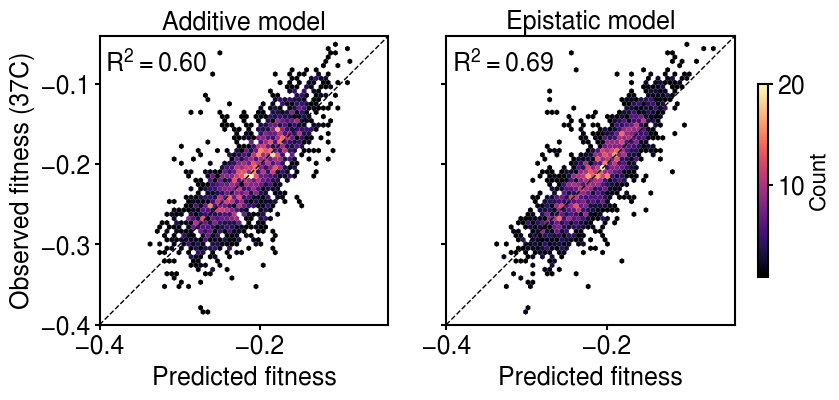

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# 1. Data setup
# Convert all tensors to numpy
x_true = test_y.cpu().detach().numpy()
y_epi = pred_epi.cpu().detach().numpy()
y_add = pred_add.cpu().detach().numpy()

# Calculate global limits for consistent 1:1 scaling
# all_vals = np.concatenate([x_true, y_epi, y_add])
# limits = [all_vals.min(), all_vals.max()]
limits = [-.4, -.04]

fontsize = 18
# 2. Style settings for "image_d53209.png" look
plt.rcParams.update({
    'font.family': 'Nimbus Sans', 
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    # --- UPDATED TICK LABEL SIZES ---
    'xtick.labelsize': fontsize,
    'ytick.labelsize': fontsize
})


# Create side-by-side figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

def plot_density_panel(ax, x, y, title):
    # Calculate R2
    r2 = pearsonr(x, y)[0]**2
    
    # Plot hexbin with 'extent' to prevent squashing
    hb = ax.hexbin(y, x, gridsize=60, cmap='magma', mincnt=1, 
                   edgecolors='none', extent=[limits[0], limits[1], limits[0], limits[1]])
    
    # 1:1 Reference Line
    ax.plot(limits, limits, color='black', linestyle='--', linewidth=1, zorder=10)
    
    # Formatting
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=fontsize, pad=5)
    ax.set_xlabel('Predicted fitness', fontsize=fontsize)
    
    # R2 Text
    ax.text(0.02, 0.95, r'$\mathregular{R^2 = ' + f'{r2:.2f}' + '}$', 
            transform=ax.transAxes, verticalalignment='top', fontsize=fontsize)
    return hb

# 3. Generate panels
hb_left = plot_density_panel(ax1, x_true, y_add, 'Additive model')
hb_right = plot_density_panel(ax2, x_true, y_epi, 'Epistatic model')

# Add y-label only to the leftmost panel
ax1.set_ylabel('Observed fitness (37C)', fontsize=fontsize)

# 4. Shared Colorbar (Single legend for count)
# 'shrink' makes the bar shorter as requested
cb = fig.colorbar(hb_right, ax=[ax1, ax2], shrink=0.5, pad=0.03)
cb.set_label('Count', size=16, labelpad=2)

plt.savefig(fig_path + 'r2_comparison_37C.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Marginal epistasis analysis

In [21]:
# Run ../scripts/2_yeast_marginals_cli.py on Slurm to get the marginal epistasis 

result_path = '../results/yeast_analysis/5_19/'

env = '37C'

marginals_add = read_marginal_results(result_path + f"yeast_marginals_k=1_env={env}.csv")

marginals_k2 = read_marginal_results(result_path + f"yeast_marginals_k=2_env={env}.csv")

marginals_k3 = read_marginal_results(result_path + f"yeast_marginals_k=3_env={env}.csv")

### Site marginals

In [22]:
from vcme.utils import get_maf

MAF = get_maf(data.geno_t)

sub = np.where(MAF > 0.10)[0] # only visualize SNPs with MAF above threshold

rescale vc to percentage
rescale vc to percentage
rescale vc to percentage


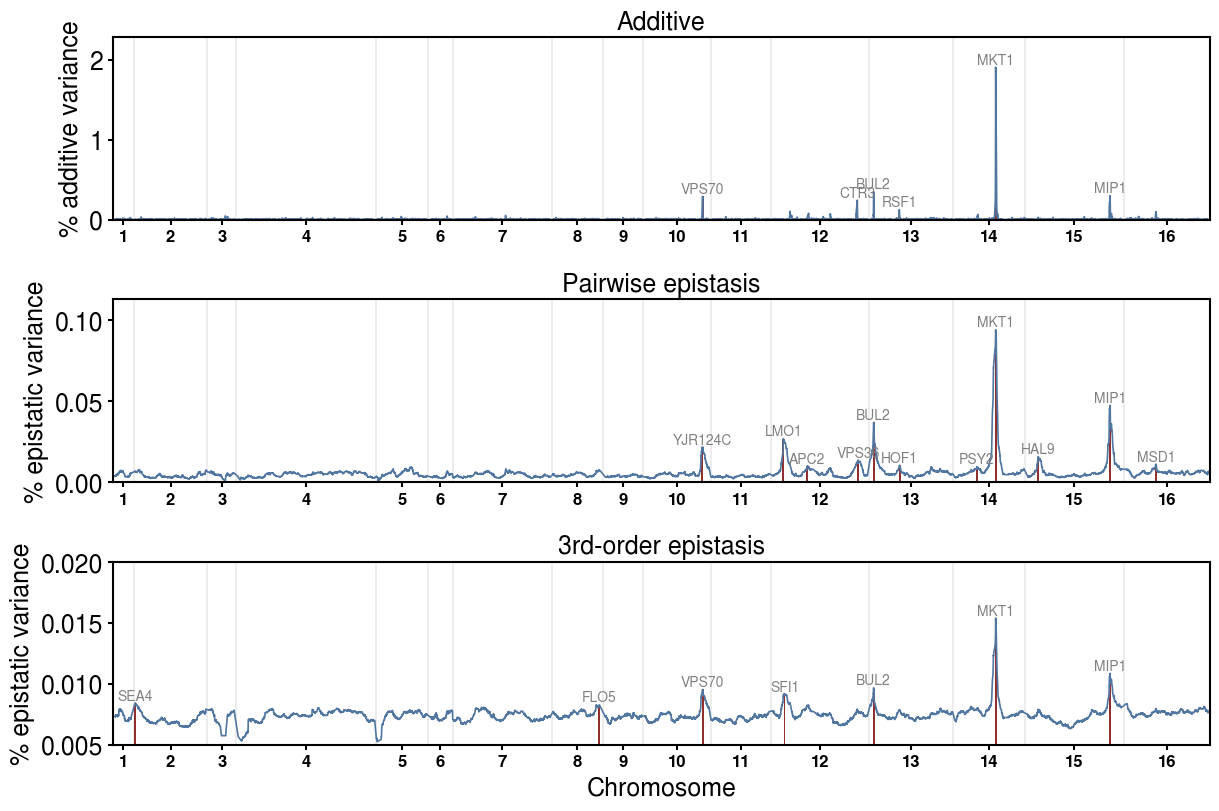

In [23]:
# Create a figure with 2 rows, 1 column
fig, (ax_top, ax_mid, ax_bottom) = plt.subplots(3, 1, figsize=(14, 8), constrained_layout=True)
fig.get_layout_engine().set(hspace=0.1)

# Call the function for both datasets using the provided axes
plot_df = marginals_add
plot_df /= plot_df.sum()
y_threshold = 100 * plot_df.effect.quantile(.998)
make_man(plot_df, genomic_meta_data.snp_info, y_threshold, 
         ylab='% additive variance', label_genes=True, ax=ax_top, title='Additive', label_x_axis=False)

plot_df = marginals_k2
plot_df /= .5 * plot_df.sum() # normalized to sum to 1
y_threshold = 100 * plot_df.effect.quantile(.95)

make_man(plot_df, genomic_meta_data.snp_info, y_threshold, 
         ylab='% epistatic variance', label_genes=True, ax=ax_mid, title='Pairwise epistasis', label_x_axis=False)


plot_df = marginals_k3
plot_df /= 1/3 * plot_df.sum() # normalized to sum to 1
plot_df = plot_df.iloc[sub]
y_threshold = 100 * plot_df.effect.quantile(.98)

make_man(plot_df, genomic_meta_data.snp_info, y_threshold, 
         ylab='% epistatic variance', label_genes=True, ax=ax_bottom, title='3rd-order epistasis', ylim=[0.005, 0.02])

plt.savefig(fig_path + f'Manhattan_plot_{env}.pdf')

plt.show()

### Zoom to Epistatic QTLs

In [252]:
marginals_k2 /= .5 * marginals_k2.sum()

In [261]:
import vcme.utils
importlib.reload(vcme.utils)
from vcme.utils import make_man, make_df_plot, plot_track

rescale vc to percentage


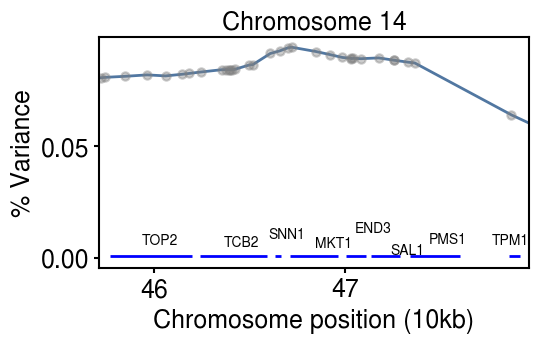

In [271]:
y_threshold = 0.01 * 0.1
pad = 10000

gene = 'MKT1'
chrom, lower, upper = get_gene_interval(gene, gene_info)

lower, upper = lower - pad, upper + pad

plot_track(marginals_k2, snp_info, gene_info, y_threshold, 'effect', 
           ylab='% Variance', chrom=chrom, chrom_range=[lower, upper])

plt.savefig(fig_path + f"qtl_{env}_gene={gene}.pdf")
plt.show()

rescale vc to percentage


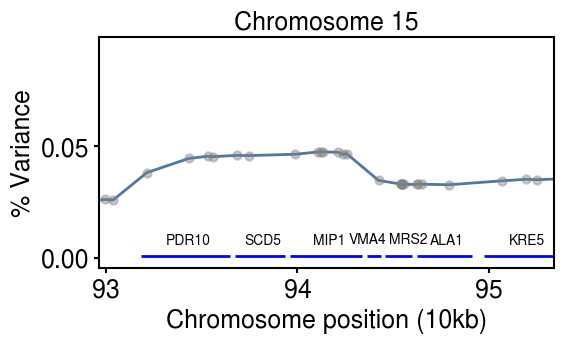

In [268]:
y_threshold = 0.01 * 0.1
pad = 10000

gene = 'MIP1'
chrom, lower, upper = get_gene_interval(gene, gene_info)

lower, upper = lower - pad, upper + pad

plot_track(marginals_k2, snp_info, gene_info, y_threshold, 'effect', 
           ylab='% Variance', chrom=chrom, chrom_range=[lower, upper])

plt.savefig(fig_path + f"qtl_{env}_gene={gene}.pdf")
plt.show()

rescale vc to percentage


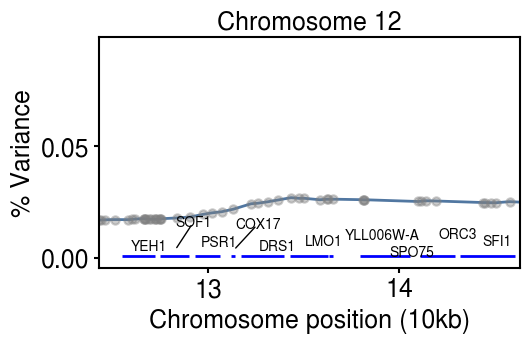

In [269]:
y_threshold = 0.01 * 0.1
pad = 10000

gene = 'LMO1'
chrom, lower, upper = get_gene_interval(gene, gene_info)

lower, upper = lower - pad, upper + pad

plot_track(marginals_k2, snp_info, gene_info, y_threshold, 'effect', 
           ylab='% Variance', chrom=chrom, chrom_range=[lower, upper])

plt.savefig(fig_path + f"qtl_{env}_gene={gene}.pdf")

plt.show()

rescale vc to percentage


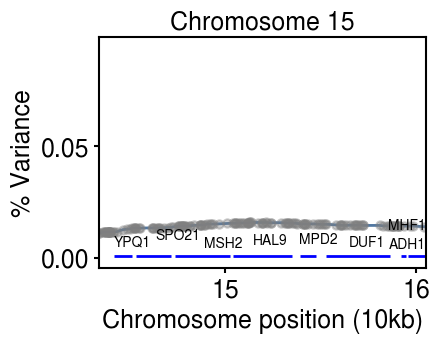

In [270]:
y_threshold = 0.01 * 0.1
pad = 7000

gene = 'HAL9'
chrom, lower, upper = get_gene_interval(gene, gene_info)

lower, upper = lower - pad, upper + pad

plot_track(marginals_k2, snp_info, gene_info, y_threshold, 'effect', 
           ylab='% Variance', chrom=chrom, chrom_range=[lower, upper])

plt.savefig(fig_path + f"qtl_{env}_gene={gene}.pdf")

plt.show()

### Examine a locus with enriched third order interactions

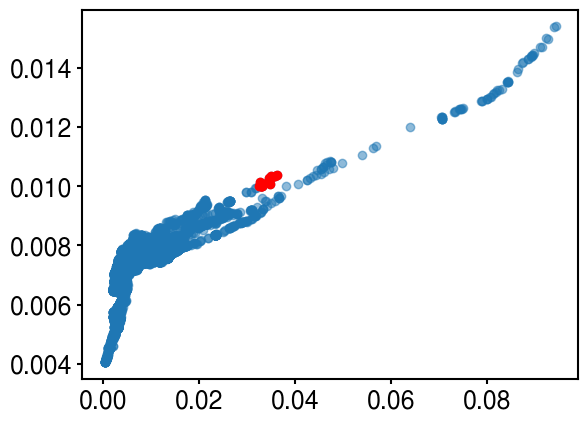

In [27]:
# Create the mask based on the visual coordinates in image_90a802.png
mask = (
    (100 * marginals_k2 > 0.03) & (100 * marginals_k2 < 0.038) & 
    (100 * marginals_k3 > 0.01) & (100 * marginals_k3 < 0.011)
)

# Pull the specific data points
outlier_points = snp_info[mask] # Or whichever dataframe contains your labels

plt.scatter(100 * marginals_k2, 100 * marginals_k3, alpha=0.5)
plt.scatter(100 * marginals_k2[mask], 100 * marginals_k3[mask], color='red')
plt.show()

In [28]:
snp_info.loc[np.where(mask)[0]]

,Unnamed: 0,chrom,snp_pos,feature_type,gene_name,gene_chr_start,gene_chr_end,distance,gene_standard_name,Index,abs_pos
39502,39502,15,944240,genic,YOR332W,943656,944357,0,VMA4,39502,10976208
39503,39503,15,945431,genic,YOR334W,944596,946008,0,MRS2,39503,10977399
39504,39504,15,945434,genic,YOR334W,944596,946008,0,MRS2,39504,10977402
39505,39505,15,945457,genic,YOR334W,944596,946008,0,MRS2,39505,10977425
39506,39506,15,945473,genic,YOR334W,944596,946008,0,MRS2,39506,10977441
39507,39507,15,945594,genic,YOR334W,944596,946008,0,MRS2,39507,10977562
39508,39508,15,946276,genic,YOR335C,946233,949109,0,ALA1,39508,10978244
39509,39509,15,946300,genic,YOR335C,946233,949109,0,ALA1,39509,10978268
39510,39510,15,946496,genic,YOR335C,946233,949109,0,ALA1,39510,10978464
39511,39511,15,947930,genic,YOR335C,946233,949109,0,ALA1,39511,10979898


rescale vc to percentage


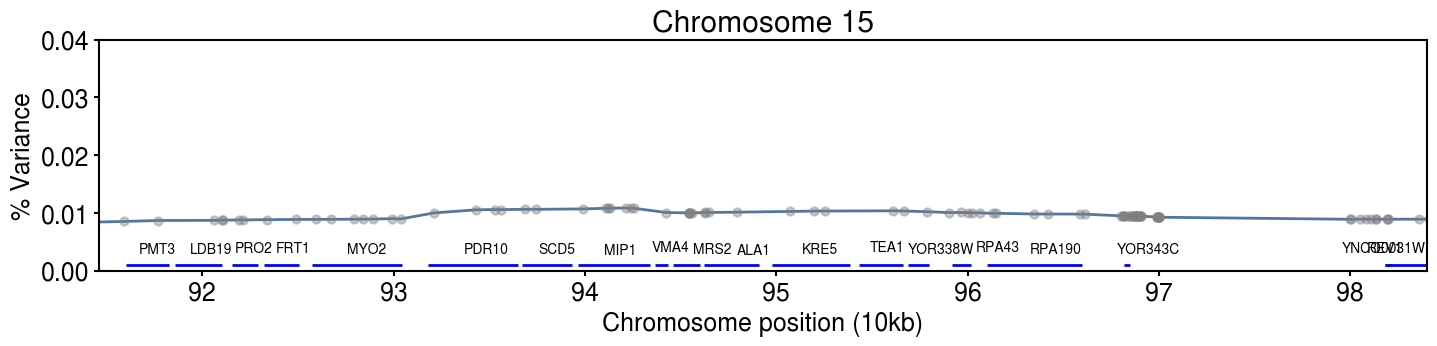

In [31]:
y_threshold = 0.01 * 0.1
pad = 30000

gene = 'MRS2'
chrom, lower, upper = get_gene_interval(gene, gene_info)

lower, upper = lower - pad, upper + pad + 8000

plot_track(marginals_k3, snp_info, gene_info, y_threshold, 'effect', 
           ylab='% Variance', chrom=chrom, chrom_range=[lower, upper], ylim=[0, .04])
# plot_track(df_plot, geno_data.snp_info, 'LOD', chrom=chrom)
plt.show()

### Chromosome interactions

In [32]:
SS_2 = marg.get_SS_k(2) # pairwise VC

In [33]:
pruned_loci = range(L)

In [34]:
from itertools import combinations

snp_info_sub = snp_info.loc[pruned_loci]

chr_snps = [np.where(snp_info_sub.chrom == i)[0] for i in range(1, 17)]
chr_pairs_snps = list(combinations(chr_snps, 2))
chr_pairs_snps += [[c, c] for c in chr_snps]

n_within_chrs =  np.sum([len(c1)**2/2 for c1 in chr_snps])/(L**2/2)
n_between_chrs = np.sum([len(pair[0]) * len(pair[1]) for pair in chr_pairs_snps[:-16]])/(L**2/2)

In [35]:
chr_pairs_no = list(combinations(list(range(16)), 2))
chr_pairs_no = list([list(p) for p in chr_pairs_no])

chr_pairs_no += [[c, c] for c in range(16)]

In [36]:
results = []

for pair in tqdm(chr_pairs_snps):
    test_stat = marg.get_gxg_interaction(*pair)
    
    results.append(test_stat)

100%|██████████| 136/136 [00:24<00:00,  5.65it/s]


In [37]:
results = np.array(results)

In [38]:
results[-16:] *= .5 # double counting for within chrom interaction

In [40]:
print(np.sum(results)/SS_2) # total interaction partitions into within chromosome and between chromosome

0.9999985198938349


In [44]:
# We want to normalize between chromosome interaction by the number of snp pairs

n_snps_per_chr = snp_info.chrom.value_counts()

n_snp_pairs = np.array([n_snps_per_chr[c[0] + 1] * n_snps_per_chr[c[1] + 1] for c in chr_pairs_no], dtype=float)
n_snp_pairs[-16:] /= 2


chr_interaction_df = pd.DataFrame({'chromosome_a': [c[0] for c in chr_pairs_no], 'chromosome_b': [c[1] for c in chr_pairs_no], 
                                   "SS": np.array(results), "n_snp_pairs": n_snp_pairs})

chr_interaction_df['VC'] = chr_interaction_df.SS/SS_2

chr_interaction_df['mean_VC'] = chr_interaction_df.VC/chr_interaction_df.n_snp_pairs

# chr_interaction_df.to_csv(result_path + 'chr_interactions.csv', index=None) # This is used to make the circos plot

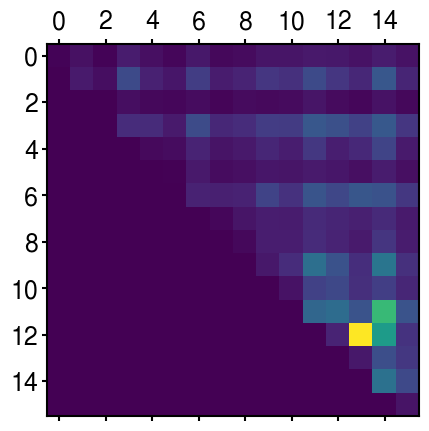

In [48]:
chr_intr = np.zeros((16, 16))

for i, p in enumerate(chr_pairs_no):
    chr_intr[tuple(p)] = results[i]

chr_intr = (chr_intr/SS_2) # matrix format

plt.matshow(chr_intr)
plt.show()

#### Compare within and between chrom interactions

In [49]:
print(f'Fraction of pairwise variance due to inter-chromosome interactions = {chr_interaction_df['VC'].iloc[:-16].sum()}')

Fraction of pairwise variance due to inter-chromosome interactions = 0.919014270430159


In [50]:
print(f'Fraction of pairwise variance due to within-chromosome interactions = {chr_interaction_df['VC'].iloc[-16:].sum()}')

Fraction of pairwise variance due to within-chromosome interactions = 0.08098424946367601


In [51]:
print(f'proportion of interactions within chroms = {n_within_chrs}, prop of interactions between chroms = {n_between_chrs}')

proportion of interactions within chroms = 0.07572487352693301, prop of interactions between chroms = 0.924275126473067


In [52]:
mean_vc_within, mean_vc_between = chr_interaction_df.mean_VC.iloc[-16:], chr_interaction_df.mean_VC.iloc[:-16]

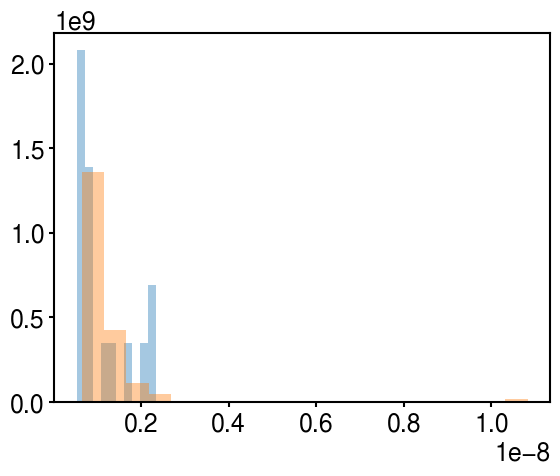

In [53]:
plt.hist(mean_vc_within, alpha=.4, density=True, bins=10)
plt.hist(mean_vc_between, alpha=.4, density=True, bins=20)
plt.show()

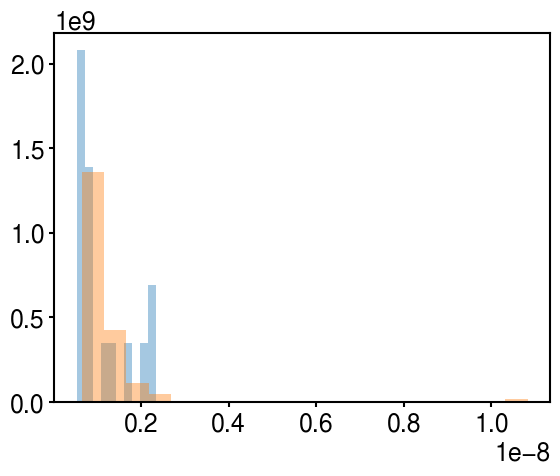

In [54]:
plt.hist(mean_vc_within, alpha=.4, density=True, bins=10)
plt.hist(mean_vc_between, alpha=.4, density=True, bins=20)
plt.show()

In [59]:
# Epistatic interaction does not seem to be enriched for within chromosome SNPs

import numpy as np
from scipy import stats

# Perform independent t-test
sample0, sample1 = mean_vc_within, mean_vc_between

## t test

sample0, sample1 = np.arcsin(np.sqrt(sample0)), np.arcsin(np.sqrt(sample1))
# t_stat, p_value = stats.ttest_ind(np.log(mean_vc_within), np.log(mean_vc_between))
t_stat, p_value = stats.ttest_ind(sample0, sample1)
print(p_value)

## Mann whitney
u_stat, p_value = stats.mannwhitneyu(sample0, sample1, alternative='two-sided')
print(p_value)

0.6376804785296306
0.15905127297732657


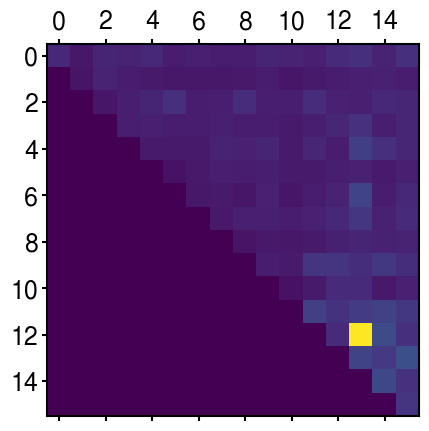

In [60]:
chr_intr = np.zeros((16, 16))

for i, p in enumerate(chr_pairs_no):
    chr_intr[tuple(p)] = chr_interaction_df.mean_VC.iloc[i]

plt.matshow(chr_intr)
plt.show()

### Gene networks and subnetworks

##### Because the gene interaction network is so dense and hard to understand, here we look at the subnetwork spanned by epistatic hub genes only
##### We can make the network figures like this
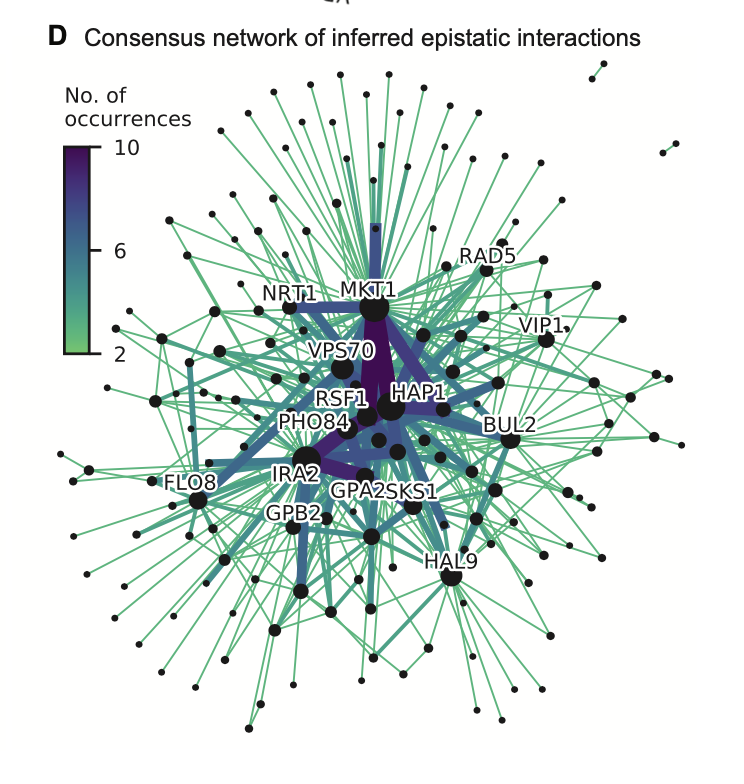

In [ ]:
# This is a list of pleotropic genes reported by the eLife paper, we will restrict to these genes
genes_desai = ["MKT1", "HAP1", "IRA2", "FLO8", "BUL2",  "PHO84", "RSF1", "VPS70", "NRT1", "RAD5", "VIP1", "GPA2", "SKS1", "GPB2", "HAL9"]

In [69]:
marginals_k2 = read_marginal_results(result_path + f"yeast_marginals_k=2_env={env}.csv")
SS_2 = .5 * marginals_k2.sum().item()
marginals_k2_percent = marginals_k2/marginals_k2.sum()

In [81]:
from tqdm import tqdm

def get_gxg(gene1, gene2):
    # function for calculating the mean interaction strength between two genes
    gene1_snps, gene2_snps = gene_snps[gene1], gene_snps[gene2]
    n = len(gene1_snps) * len(gene2_snps)
    return marg.get_gxg_interaction(gene1_snps, gene2_snps)/n

In [181]:
import importlib
importlib.reload(vcme.utils)
from vcme.utils import make_df_plot

percent_threshold = 0.1 # in unit of percentage
_, df_plot_max = make_df_plot(marginals_k2_percent, snp_info, y_threshold=0.0)

rescale vc to percentage


In [135]:
def get_nearby_genes(gene):
    pos = np.where(gene_info.gene_standard_name == gene)[0][0]
    gene_info_sub = gene_info.iloc[pos - 5:pos + 5]
    return list(gene_info_sub.gene_standard_name)

In [136]:
# Replace top gene names with gene names identified by the Desai paper

top_genes = []

for gene in df_plot_max.gene:
    intersect = set(get_nearby_genes(gene)).intersection(genes_desai)
    if len(intersect) == 0:
        top_genes.append(gene)
    else:
        top_genes.append(list(intersect)[0])

top_genes = list(set(top_genes))

print(len(top_genes))

132


In [94]:
results = []

for gene in top_genes:
    print(f'working on gene {gene}')
    out = [get_gxg(gene, gene2) for gene2 in tqdm(genes)]
    out = pd.DataFrame(out)
    out.insert(0, 'gene2', genes)    
    out.insert(0, 'gene1', [gene for _ in range(len(genes))])
    results.append(out)

In [82]:
top_gene_interactions = pd.concat(results, axis=0)

top_gene_interactions.rename(columns={top_gene_interactions.columns[-1]: 'mean_VC'}, inplace=True)

top_gene_interactions['mean_VC'] = top_gene_interactions['mean_VC']/SS_2

In [83]:
top_gene_interactions.sort_values(by='mean_VC', ascending=False)

,gene1,gene2,mean_VC
3416,MKT1,BUL2,1.656516e-08
3983,BUL2,MKT1,1.656516e-08
3417,MKT1,COQ5,1.641006e-08
3984,BUL2,END3,1.636295e-08
3985,BUL2,SAL1,1.629380e-08
...,...,...,...
1153,VPS70,HSP31,1.365300e-14
1719,KRE5,PRP18,1.329256e-14
2462,KRE5,TRL1,1.246566e-14
1721,KRE5,STF2,1.056921e-14


In [84]:
top_gene_interactions.to_csv("../results/yeast_analysis/top_gene_interactions.tsv") # this is used to plot the subnetwork

In [182]:
# get null distribution by sampling random gene pairs

from itertools import combinations

gene_pairs = list(combinations(genes, 2))

gene_pairs_sample = random.sample(gene_pairs, 10000)

results_gxg_null = []

for pair in tqdm(gene_pairs_sample):
    test_stat = get_gxg(*pair)
    
    results_gxg_null.append(test_stat)

results_gxg_null = np.array(results_gxg_null)
results_gxg_null /= SS_2

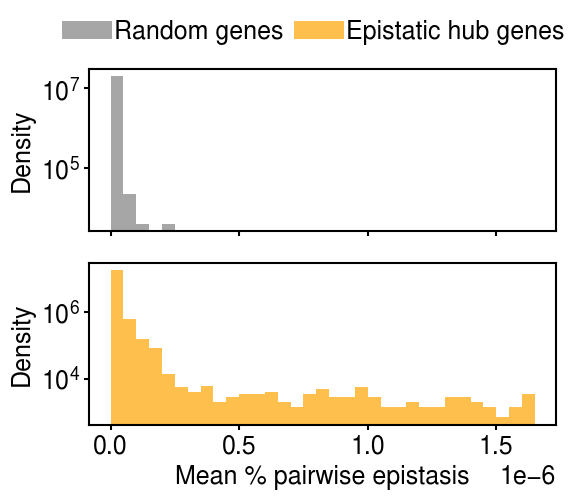

In [162]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker  # Imported to control tick placement
import numpy as np

# --- Global Font Settings ---
plt.rcParams.update({
    'font.size': 18,               
    'axes.labelsize': 18,          
    'axes.titlesize': 18,          
    'xtick.labelsize': 18,         
    'ytick.labelsize': 18,         
    'legend.fontsize': 18,         
    'font.family': 'sans-serif',   
    'font.sans-serif': ['Nimbus Sans', 'Helvetica', 'Arial'] 
})

# --- Data & Bins Setup (Multiplied by 100) ---
# Scale the base data by 100
scaled_null = results_gxg_null * 100
scaled_hub = top_gene_interactions.mean_VC * 100

# Re-calculate bins based on the scaled data
bin_width = (.05 * 10**-8) * 100
bins = np.arange(min(scaled_hub), max(scaled_hub) + .1 * bin_width, bin_width)

# Create a 2-row, 1-column subplot structure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

# --- Top Panel: Null Distribution ---
ax1.hist(scaled_null, density=True, log=True, bins=bins, 
         color='gray', edgecolor='none', alpha=0.7, 
         label='Random genes')
ax1.set_ylabel('Density')

# Force y-axis to only show whole number powers of 10
ax1.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=[1.0]))
ax1.yaxis.set_minor_locator(ticker.NullLocator()) # Removes any tiny sub-ticks

# --- Bottom Panel: Epistatic Hubs ---
ax2.hist(scaled_hub, density=True, log=True, bins=bins, 
         color='orange', edgecolor='none', alpha=0.7, 
         label='Epistatic hub genes')
ax2.set_ylabel('Density')
ax2.set_xlabel('Mean % pairwise epistasis')

# Force y-axis to only show whole number powers of 10
ax2.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=[1.0]))
ax2.yaxis.set_minor_locator(ticker.NullLocator()) # Removes any tiny sub-ticks

# --- Extract Visual Handles Automatically ---
handle1, _ = ax1.get_legend_handles_labels()
handle2, _ = ax2.get_legend_handles_labels()

# --- Single Unified Figure Legend ---
fig.legend(handles=[handle1[0], handle2[0]], 
           labels=['Random genes', 'Epistatic hub genes'], 
           loc='lower center',        
           bbox_to_anchor=(0.55, 0.9), 
           ncol=2,                      
           frameon=False,
           columnspacing=.4,          
           handletextpad=0.1)

# Clean up layout 
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(fig_path + 'Gene_interaction_strength_distribution.pdf')
plt.show()

### Yeast Pathway epistatic marginals - class

In [25]:
from vcme.pathway_analysis import pathway_analysis

In [28]:
pa = pathway_analysis(
    marg=marg,
    snp_info=snp_info,
    gene_sets=genomic_meta_data.pathway_genes,
    geno_t=data.geno_t
)

# df_pathway_enrich_epistatic = pa.run_epistatic_enrichment(
#     geno_t=data.geno_t,
#     n_samples=200,
#     pathway_info_dir="../data/yeast/pathway_info"
# )


IndexError: index 1 is out of bounds for dimension 0 with size 1

In [14]:
gene = list(gene_snps.keys())[51]
print(len(gene_snps[gene]), pa.gene_LD[gene])

NameError: name 'gene_snps' is not defined

In [321]:
for _ in range(20):
    gene_sample = pa.sample_rand_gene(gene)
    print(gene_sample, len(gene_snps[gene_sample]), pa.gene_LD[gene_sample])

YIR032C 9 0.9965428709983826
YGL222C 7 0.9949434995651245
YDR496C 10 0.9970390796661377
YOR057W 12 0.9966602921485901
YBL030C 10 0.9933444857597351
YBR152W 10 0.9970832467079163
YPR112C 9 0.9918408393859863
YGR004W 9 0.9996401071548462
YJR088C 8 0.998708188533783
YDL216C 10 0.994102418422699
YNL288W 10 0.9950546026229858
YLR240W 11 0.9953601956367493
YLR172C 10 0.9975391626358032
YKR075C 9 0.9845987558364868
YDL130W 8 0.9963871836662292
YPL066W 11 0.9880009293556213
YKR068C 14 0.9958183765411377
YLR079W 7 0.9976423978805542
YIL153W 10 0.9881012439727783
YBR204C 10 0.9943386912345886


In [325]:
pwy = pathways[2]

In [326]:
genes = pa.gene_sets[pwy]
print(genes)

[[len(gene_snps[gene]), pa.gene_LD[gene]] for gene in genes]

['YHR025W', 'YDR158W', 'YCR053W', 'YER052C', 'YKL106W', 'YBR218C', 'YLR027C', 'YGL062W']


[[11, np.float64(0.9944734573364258)],
 [1, np.float64(1.0)],
 [4, np.float64(0.9949626326560974)],
 [5, np.float64(0.9982393980026245)],
 [9, np.float64(0.9928067922592163)],
 [13, np.float64(0.9604658484458923)],
 [8, np.float64(0.9923937320709229)],
 [21, np.float64(0.9904922246932983)]]

In [327]:
genes = pa.sample_null_pathway(pwy)

print(genes)

[[len(gene_snps[gene]), pa.gene_LD[gene]] for gene in genes]

['YOL140W', 'YJL205C', 'YEL029C', 'YLR153C', 'YMR160W', 'YKL213C', 'YPL011C', 'YKL162C-A']


[[11, np.float64(0.995532214641571)],
 [2, np.float64(0.9998904466629028)],
 [4, np.float64(0.9988387227058411)],
 [4, np.float64(0.999947190284729)],
 [9, np.float64(0.986605167388916)],
 [13, np.float64(0.9924472570419312)],
 [8, np.float64(0.9952268600463867)],
 [20, np.float64(0.9977544546127319)]]

### Yeast Pathway epistatic marginals - old

In [29]:
SS_total = marg.get_SS_k(2)


IndexError: index 1 is out of bounds for dimension 0 with size 1

In [187]:

# pathway to genes

pathways = genomic_meta_data.pathways

pathway_info = {}
for pwy in pathways:

    with open(f"../data/yeast/pathway_info/{pwy}.txt", 'r', encoding='utf-8') as file:
        description = file.readline().rstrip('\n')
    pathway_info[pwy] = description
    
pathway_genes = genomic_meta_data.pathway_genes

# genes to snps

genes = snp_info.gene_name.unique()

gene_snps = {}

for g in genes:
    snps = list(snp_info.index[snp_info.gene_name == g])
    gene_snps[g] = snps
    
gene_sizes = pd.Series({gene: len(gene_snps[gene]) for gene in gene_snps.keys()})     

# calculate LD within individual genes

geno_t = data.geno_t
def calculate_LD(snps):
    if len(snps) < 2:
        return 1
    else:
        G = geno_t[:, snps]
        R = torch.corrcoef(geno_t[:, snps].t())**2
        mask = torch.triu(torch.ones_like(R)).bool()
        return R[mask].mean().item()
    
out = {}
for gene in gene_snps.keys(): 
    try: 
        ld = calculate_LD(gene_snps[gene])
    except: 
        ld = None

    out[gene] = ld
gene_LD = pd.Series(out)



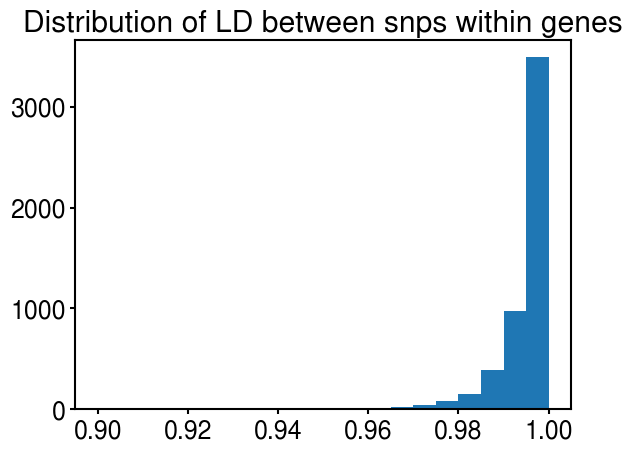

In [188]:
plt.hist(gene_LD, range=[.9, 1], bins=20)
plt.title("Distribution of LD between snps within genes")
plt.show()

#### Enrichment p values

In [189]:
def sample_rand_gene(gene):

    snps = gene_snps[gene]
    LD = calculate_LD(snps) # LD between snps within the gene
    size = len(snps) # Number of snps in the gene

    weights_size = np.exp(-np.abs((gene_sizes - size))) # weights based on gene size differences
    weights_LD = np.exp(-np.abs((gene_LD - LD))) # weights based on LD differences

    weights_size = weights_size.drop(gene)
    weights_LD = weights_LD.drop(gene)

    genes_sub_sampled = np.random.choice(weights_size.index, p=weights_size / weights_size.sum(), size=10)    
    genes_sub_sampled = list(genes_sub_sampled)


    weights_LD_sub = weights_LD.loc[genes_sub_sampled]

    gene_sampled = np.random.choice(weights_LD_sub.index, p=weights_LD_sub / weights_LD_sub.sum())    
    
    return gene_sampled

def sample_null_pathway(pathway):
    gene_snps_sample = []
    genes_in_pathway = pathway_genes[pathway]
    for gene in genes_in_pathway:
        snps = gene_snps[gene]
        if snps == []:
            pass
        else: 
            gene_sample = sample_rand_gene(gene)
            gene_snps_sample.append(gene_snps[gene_sample])
    return gene_snps_sample

In [190]:
pathways = list(set(pathways))
print(len(pathways))

# results = pd.read_csv(out_path + "pathway_marginals.csv")
# results = dict(zip(results.iloc[:, 0], results.iloc[:, 1]))

123


In [191]:
pathway_ss_epistatic = {}

for pathway in tqdm(pathways): 
    genes_in_pathway = pathway_genes[pathway]
    snp_list = [gene_snps[gene] for gene in genes_in_pathway]
    snp_list = [sublist for sublist in snp_list if sublist] # remove all empty lists
    if len(snp_list) == 0:
        out = 0
    else: out = marg.get_pathway_interaction(snp_list)
    pathway_ss_epistatic[pathway] = out


100%|██████████| 123/123 [00:06<00:00, 18.64it/s]


In [405]:
# get p value by comparing pathway marginal against null distribution for random gene sets
# random gene sets have the same number of genes as the test pathway, with random genes sampled by matching LD and number of snps

pathway_samples_epistatic = {}

for pathway in tqdm(pathways): 
    genes_in_pathway = pathway_genes[pathway]
    snp_list = [gene_snps[gene] for gene in genes_in_pathway]
    snp_list = [sublist for sublist in snp_list if sublist] # remove all empty lists        
    
    if len(snp_list) > 1:    
        test_stat = marg.get_pathway_interaction(snp_list)        
        samples = []
        for _ in range(200):
            pathway_snps_sample = sample_null_pathway(pathway)
            sample_stat = marg.get_pathway_interaction(pathway_snps_sample)
            samples.append(sample_stat)
        pathway_samples_epistatic[pathway] = samples
    else: pass

100%|██████████| 123/123 [07:48<00:00,  3.81s/it]


In [471]:
# # pwy = 'PWY-922'
# print(pwy)

# import seaborn as sns

# plt.hist(
#     pathway_samples_epistatic[pwy], 
#     bins=20, 
#     edgecolor='black', 
#     color='skyblue', 
#     alpha=0.8, 
#     label='Sample Distribution'
# )
# v_line = pathway_ss_epistatic[pwy]
# plt.axvline(x=v_line)

In [477]:
pathway_p_values_epistatic = {}

for pathway in tqdm(pathways): 
    test_stat = pathway_ss_epistatic[pathway]
    try:
        samples = pathway_samples_epistatic[pathway]
        percentile = np.mean(np.array(samples) <= test_stat)
        pathway_p_values_epistatic[pathway] = 1 - percentile.item()
    except:
        pass

100%|██████████| 123/123 [00:00<00:00, 77942.20it/s]


In [552]:
pathway_p_values_epistatic = pd.Series(pathway_p_values_epistatic)
pathway_p_values_epistatic = pathway_p_values_epistatic.sort_values()

pathway_ss_epistatic = pd.Series(pathway_ss_epistatic)

df_pathway_enrich_epistatic = pd.concat([pathway_ss_epistatic, pathway_p_values_epistatic], axis=1, join='inner', keys=['SS', 'p_value'])

df_pathway_enrich_epistatic['description'] = [pathway_info[pwy] for pwy in df_pathway_enrich_epistatic.index]

df_pathway_enrich_epistatic.sort_values(by='p_value', inplace=True)

df_pathway_enrich_epistatic.iloc[:10, 1:3].to_csv("../results/yeast_analysis/37C_top_epistatic_pathways.tsv")

#### Additive 

In [338]:
# marg.get_SS_position(orders, p)

In [486]:
site_add_df = marginals_add.copy()

In [487]:
def mean_VC(snp_list):
    snp_list = sum(snp_list, [])
    return site_add_df.loc[snp_list].effect.mean()

In [489]:
pathway_p_values = {}

for pathway in tqdm(pathways):
    genes_in_pathway = pathway_genes[pathway]
    snp_list = [gene_snps[gene] for gene in genes_in_pathway]
    snp_list = [sublist for sublist in snp_list if sublist] # remove all empty lists
    test_stat = mean_VC(snp_list)
    if len(snp_list) > 1:
        samples = []
        for _ in range(200):
            pathway_snps_sample = sample_null_pathway(pathway)
            sample_stat = mean_VC(pathway_snps_sample)
            samples.append(sample_stat)
        percentile = np.mean(np.array(samples) <= test_stat)
        pathway_p_values[pathway] = 1 - percentile
    else: pass

100%|██████████| 123/123 [03:38<00:00,  1.78s/it]


In [492]:
pathway_p_values_additive = pd.Series(pathway_p_values).sort_values()

In [499]:
pathway_p_values_epistatic[:10]

PWY3O-19      0.000
PWY3O-862     0.010
PWY3O-402     0.020
PWY-922       0.040
PWY3O-6-1     0.045
PWY-5651      0.060
PWY3O-261     0.070
PWY3O-5962    0.070
PWY3O-242     0.080
PWY-7221      0.090
dtype: float64

/blue/juannanzhou/juannanzhou/vcme_project/src/vcme/utils.py:554: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.show()
/blue/juannanzhou/juannanzhou/vcme_project/src/vcme/utils.py:554: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.show()
/blue/juannanzhou/juannanzhou/conda/envs/gpy4/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


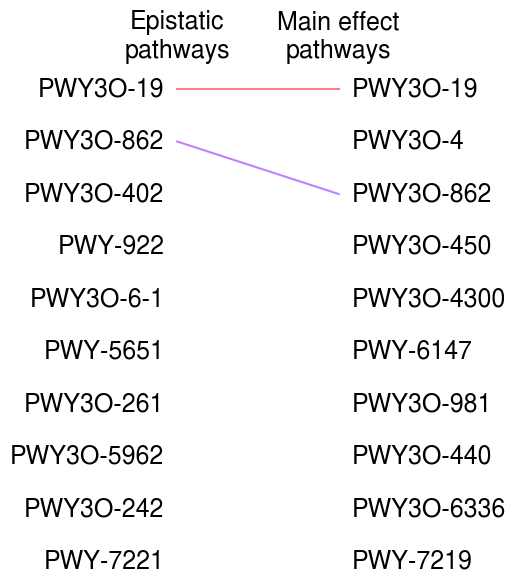

In [573]:
importlib.reload(vcme.utils)

from vcme.utils import plot_rank_overlap

plt.rcParams.update({
    "font.size":   18,
    "font.family": "nimbus sans"
})

plot_rank_overlap(pathway_p_values_epistatic[:10], pathway_p_values_additive[:10], figsize=(5, 1.5), fig_path=fig_path, fig_name='top_pathways_comparison.pdf')

attachment:ebd237f2-b111-44d3-98cf-082bbd936d7a.png

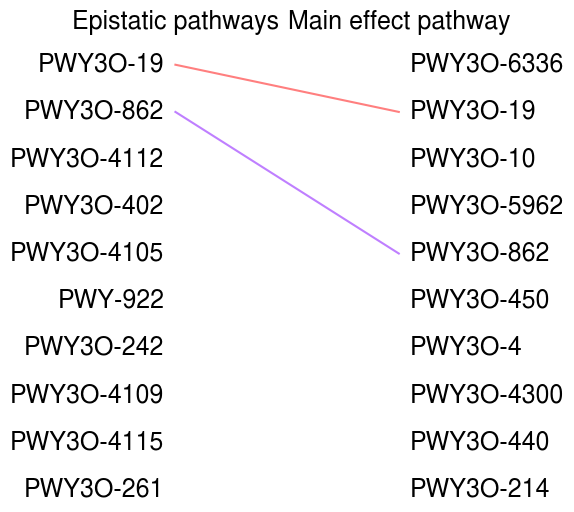

In [366]:
importlib.reload(vcme.utils)

from vcme.utils import plot_rank_overlap

plot_rank_overlap(pathway_p_values_epistatic[:10], pathway_p_values_additive[:10], figsize=(6, 20))

### KEGG

In [17]:
import gseapy as gp

In [18]:
gmt = gp.get_library(name='KEGG_2018', organism='Yeast')

In [20]:
for GO in gmt.keys(): 
    gene_set = gmt[GO]

In [25]:
def filter_gene_set(gene_set):
    return gene_set[[g in list(gene_info.gene_standard_name) for g in gene_set]]

In [26]:
for g in gmt.keys():
    gene_set = np.array(gmt[g])
    gmt[g] = filter_gene_set(gene_set)

In [32]:
pathways = list(gmt.keys())

In [33]:
pathway_genes = gmt

In [43]:
name_mapping = (
    gene_info.dropna(subset=["gene_standard_name"])
    .set_index("gene_standard_name")["gene_name"]
    .to_dict()
)

pathway_genes = {
    pathway: np.array([name_mapping.get(gene, gene) for gene in genes_array])
    for pathway, genes_array in pathway_genes.items()
}

In [54]:
pathway_ss_epistatic = {}

for pathway in tqdm(pathways): 
    genes_in_pathway = pathway_genes[pathway]
    snp_list = [gene_snps[gene] for gene in genes_in_pathway]
    snp_list = [sublist for sublist in snp_list if sublist] # remove all empty lists
    if len(snp_list) == 0:
        out = 0
    else: out = marg.get_pathway_interaction(snp_list)
    pathway_ss_epistatic[pathway] = out


100%|██████████| 133/133 [00:04<00:00, 29.80it/s]


In [47]:
pathway_samples_epistatic = {}

for pathway in tqdm(pathways): 
    genes_in_pathway = pathway_genes[pathway]
    snp_list = [gene_snps[gene] for gene in genes_in_pathway]
    snp_list = [sublist for sublist in snp_list if sublist] # remove all empty lists        
    
    if len(snp_list) > 1:    
        test_stat = marg.get_pathway_interaction(snp_list)        
        samples = []
        for _ in range(200):
            pathway_snps_sample = sample_null_pathway(pathway)
            sample_stat = marg.get_pathway_interaction(pathway_snps_sample)
            samples.append(sample_stat)
        pathway_samples_epistatic[pathway] = samples
    else: pass

100%|██████████| 133/133 [52:03<00:00, 23.48s/it]


In [53]:
import pickle

with open('pathway_samples_epistatic.pkl', 'wb') as file:
    pickle.dump(pathway_samples_epistatic, file)

In [471]:
# # pwy = 'PWY-922'
# print(pwy)

# import seaborn as sns

# plt.hist(
#     pathway_samples_epistatic[pwy], 
#     bins=20, 
#     edgecolor='black', 
#     color='skyblue', 
#     alpha=0.8, 
#     label='Sample Distribution'
# )
# v_line = pathway_ss_epistatic[pwy]
# plt.axvline(x=v_line)

In [55]:
pathway_p_values_epistatic = {}

for pathway in tqdm(pathways): 
    test_stat = pathway_ss_epistatic[pathway]
    try:
        samples = pathway_samples_epistatic[pathway]
        percentile = np.mean(np.array(samples) <= test_stat)
        pathway_p_values_epistatic[pathway] = 1 - percentile.item()
    except:
        pass

100%|██████████| 133/133 [00:00<00:00, 20921.97it/s]


In [57]:
pathway_p_values_epistatic = pd.Series(pathway_p_values_epistatic)
pathway_p_values_epistatic = pathway_p_values_epistatic.sort_values()

pathway_ss_epistatic = pd.Series(pathway_ss_epistatic)

df_pathway_enrich_epistatic = pd.concat([pathway_ss_epistatic, pathway_p_values_epistatic], axis=1, join='inner', keys=['SS', 'p_value'])

In [58]:
df_pathway_enrich_epistatic.sort_values(by='p_value', inplace=True)

In [70]:
df_pathway_enrich_epistatic.to_csv("df_pathway_enrich_epistatic.tsv")

In [62]:
df_pathway_enrich_epistatic.head(20)

,SS,p_value
Ubiquinone and other terpenoid-quinone biosynthesis sce00130,1.035419e-14,0.005
AGE-RAGE signaling pathway in diabetic complications sce04933,4.593782e-15,0.010
RNA polymerase sce03020,4.252601e-14,0.015
Aminoacyl-tRNA biosynthesis sce00970,7.016139e-14,0.015
Amino acid related enzymes sce01007,1.784285e-13,0.020
Mitochondrial biogenesis sce03029,1.576926e-12,0.040
Pyrimidine metabolism sce00240,1.891375e-13,0.065
"Valine, leucine and isoleucine degradation sce00280",8.223539e-15,0.085
DNA replication proteins sce03032,5.887139e-13,0.090
Terpenoid backbone biosynthesis sce00900,1.321567e-14,0.090


#### Additive 

In [63]:
# marg.get_SS_position(orders, p)

In [67]:
site_add_df = marginals_add.copy()

In [68]:
def mean_VC(snp_list):
    snp_list = sum(snp_list, [])
    return site_add_df.loc[snp_list].effect.mean()

In [69]:
pathway_p_values = {}

for pathway in tqdm(pathways):
    genes_in_pathway = pathway_genes[pathway]
    snp_list = [gene_snps[gene] for gene in genes_in_pathway]
    snp_list = [sublist for sublist in snp_list if sublist] # remove all empty lists
    test_stat = mean_VC(snp_list)
    if len(snp_list) > 1:
        samples = []
        for _ in range(200):
            pathway_snps_sample = sample_null_pathway(pathway)
            sample_stat = mean_VC(pathway_snps_sample)
            samples.append(sample_stat)
        percentile = np.mean(np.array(samples) <= test_stat)
        pathway_p_values[pathway] = 1 - percentile
    else: pass

100%|██████████| 133/133 [36:05<00:00, 16.28s/it]


In [71]:
pathway_p_values_additive = pd.Series(pathway_p_values).sort_values()

In [75]:
pathway_p_values_additive

Mismatch repair  sce03430                                        0.005
Ubiquinone and other terpenoid-quinone biosynthesis  sce00130    0.025
Propanoate metabolism  sce00640                                  0.065
Fatty acid biosynthesis  sce00061                                0.070
DNA replication proteins  sce03032                               0.070
                                                                 ...  
Protein export  sce03060                                         0.980
Proteasome  sce03051                                             0.990
Fatty acid degradation  sce00071                                 0.995
beta-Alanine metabolism  sce00410                                0.995
Nucleotide excision repair  sce03420                             1.000
Length: 133, dtype: float64

/blue/juannanzhou/juannanzhou/vcme_project/src/vcme/utils.py:554: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig(fig_path + fig_name, bbox_inches="tight")
/blue/juannanzhou/juannanzhou/vcme_project/src/vcme/utils.py:554: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig(fig_path + fig_name, bbox_inches="tight")
/blue/juannanzhou/juannanzhou/conda/envs/gpy4/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


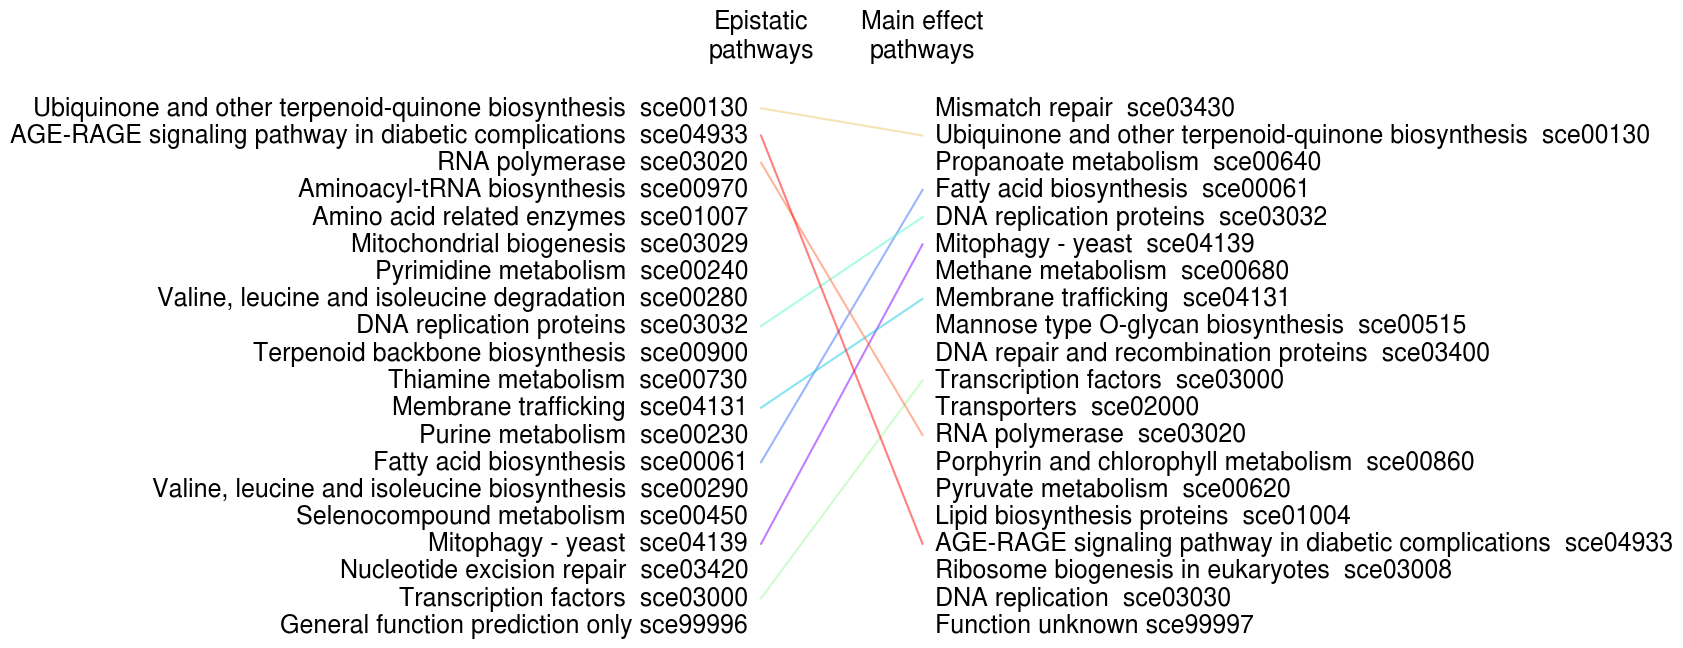

In [76]:
importlib.reload(vcme.utils)

from vcme.utils import plot_rank_overlap

plt.rcParams.update({
    "font.size":   18,
    "font.family": "nimbus sans"
})

plot_rank_overlap(pathway_p_values_epistatic[:20], pathway_p_values_additive[:20], 
                  figsize=(5, 7), fig_path=fig_path, fig_name='top_pathways_comparison.pdf')

### Pathway cross talk